In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import r2_score , mean_squared_error , root_mean_squared_error
import warnings 
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('Salary_Data.csv')
data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [3]:
x = data.iloc[: , :-1]
y = data.iloc[:, 1]
x_train , x_test , y_train , y_test = train_test_split(x , y , train_size = 0.8 , random_state = 10 )

In [4]:
x_train

,YearsExperience
13,4.1
27,9.6
12,4.0
1,1.3
19,6.0
14,4.5
18,5.9
6,3.0
11,4.0
23,8.2


In [5]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree= 15 )
x_poly_train = poly.fit_transform(x_train)
x_poly_test  = poly.transform(x_test)

poly_model = LinearRegression()
poly_model.fit(x_poly_train , y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
y_poly_pred_train = poly_model.predict(x_poly_train)
y_poly_pred_test = poly_model.predict(x_poly_test)

In [7]:
x_range = np.linspace(x.min(), x.max() , 100).reshape(-1 , 1)
x_range_poly = poly.transform(x_range)
y_range_pred = poly_model.predict(x_range_poly)

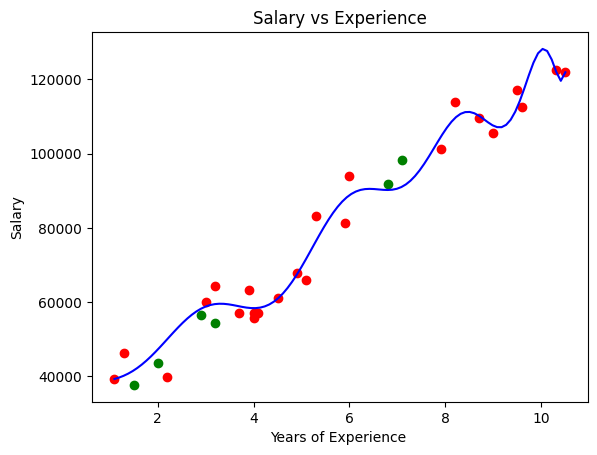

In [8]:
plt.scatter(x_train , y_train , color = 'red' , label = 'Training Data')
plt.scatter(x_test , y_test , color = 'Green' , label = 'Testing Data ')
plt.plot(x_range , y_range_pred , color = 'blue' , label = 'polynomial Regression')
plt.title("Salary vs Experience")
plt.xlabel("Years of Experience ")
plt.ylabel("Salary")
plt.legend
plt.show()

In [9]:
mse = root_mean_squared_error(y_test , y_poly_pred_test)
print(mse)

4294.262161626845


In [10]:
r2 = r2_score(y_test , y_poly_pred_test)
print(r2)

0.9654054168150664


In [11]:
data = pd.read_csv('Social_Network_Ads.csv')
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [19]:
x = data.iloc[ : , [2 , 3]].values
y = data.iloc[: , 4].values
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size= 0.2 , random_state= 10 )

In [13]:
from sklearn.preprocessing import StandardScaler 
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)

In [14]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(x_train , y_train)
y_pred = classifier.predict(x_test)